#  Credit Card Fraud Detection using Machine Learning

## Project Overview

Credit card fraud detection aims to identify fraudulent transactions from legitimate ones using machine learning techniques.

In this project, we analyze transaction data, perform exploratory data analysis, build a Logistic Regression model, and evaluate its performance to detect fraudulent transactions.

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

## Load Dataset

In [5]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## Dataset Shape

Check the number of rows and columns present in the dataset.

In [6]:
df.shape

(188261, 31)

## Dataset Information

Display information about data types and non-null values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188261 entries, 0 to 188260
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    188261 non-null  float64
 1   V1      188261 non-null  float64
 2   V2      188261 non-null  float64
 3   V3      188261 non-null  float64
 4   V4      188261 non-null  float64
 5   V5      188261 non-null  float64
 6   V6      188261 non-null  float64
 7   V7      188261 non-null  float64
 8   V8      188261 non-null  float64
 9   V9      188261 non-null  float64
 10  V10     188261 non-null  float64
 11  V11     188261 non-null  float64
 12  V12     188261 non-null  float64
 13  V13     188260 non-null  float64
 14  V14     188260 non-null  float64
 15  V15     188260 non-null  float64
 16  V16     188260 non-null  float64
 17  V17     188260 non-null  float64
 18  V18     188260 non-null  float64
 19  V19     188260 non-null  float64
 20  V20     188260 non-null  float64
 21  V21     18

## Check Missing Values

Verify whether the dataset contains missing values.

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Statistical Summary

Generate descriptive statistics for numerical features.

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,...,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000
mean,66911.456133,-0.126822,0.014291,0.382492,0.088906,-0.135514,0.051997,-0.062135,0.022762,0.012470,...,-0.018643,-0.060736,-0.018176,0.006076,0.072208,0.008481,0.001743,0.002159,89.001873,0.001955
std,32193.455193,1.880580,1.617636,1.428443,1.390410,1.356318,1.306515,1.212057,1.215524,1.141162,...,0.740575,0.683142,0.602327,0.602126,0.481530,0.489465,0.392296,0.309245,247.536677,0.044169
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,43063.000000,-0.969960,-0.568821,-0.232844,-0.777499,-0.800564,-0.702594,-0.580756,-0.174494,-0.661910,...,-0.228172,-0.540946,-0.169179,-0.338314,-0.225180,-0.331167,-0.066674,-0.037728,5.947500,0.000000
50%,64747.000000,-0.121054,0.088501,0.542372,0.091115,-0.190869,-0.212486,-0.018999,0.047961,-0.075250,...,-0.047004,-0.046416,-0.031424,0.055086,0.116006,-0.060301,0.006936,0.019435,22.740000,0.000000
75%,84168.000000,1.202527,0.788329,1.252559,0.905617,0.432033,0.446707,0.485381,0.342508,0.630737,...,0.143128,0.401626,0.109334,0.419810,0.389857,0.265841,0.089280,0.078149,79.000000,0.000000
max,127894.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


## Anomaly Detection

Fraudulent transactions are anomalies because they occur much less frequently than legitimate transactions.

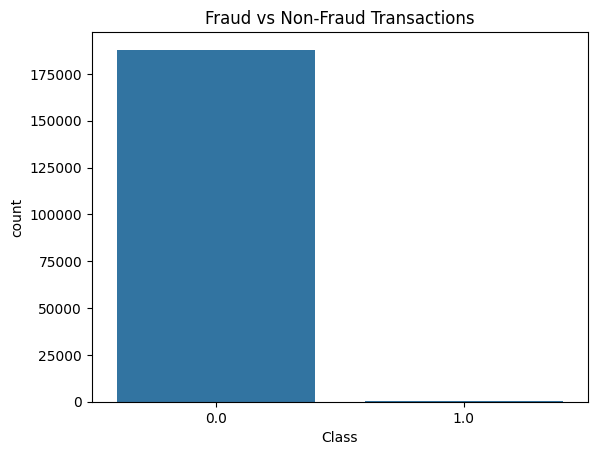

In [10]:
sns.countplot(x="Class",data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

##Interpretation

The visualization shows that the dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of all transactions. Detecting these rare anomalies is the primary challenge in fraud detection.

## Feature Engineering

Separate the input features and target variable for model training.

In [15]:
X = df.drop("Class",axis=1)

y = df["Class"]

## Train-Test Split

Split the dataset into training and testing sets.

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Machine Learning Model

Logistic Regression is used to classify transactions as fraudulent or legitimate.

In [19]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [20]:
df = df.dropna()

In [22]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [24]:
y_pred=model.predict(X_test)

In [25]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9988048443641772


##Interpretation

Logistic Regression learns transaction patterns from historical data and predicts whether a new transaction is fraudulent or legitimate. It serves as a reliable baseline model for binary fraud classification.

## Classification Report

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     37581
         1.0       0.73      0.58      0.65        71

    accuracy                           1.00     37652
   macro avg       0.87      0.79      0.82     37652
weighted avg       1.00      1.00      1.00     37652



## Confusion Matrix

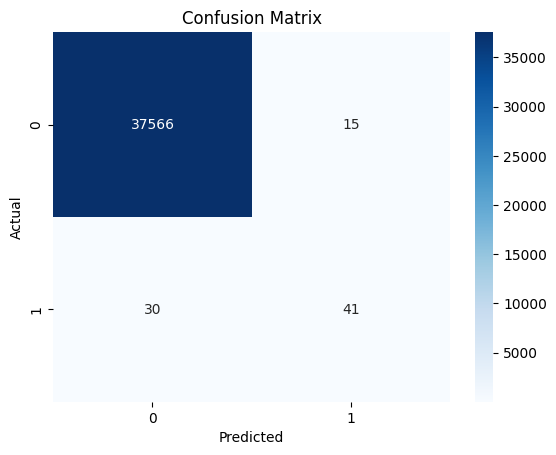

In [27]:
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

##Interpretation

The confusion matrix summarizes the model's predictions. Most values on the diagonal indicate correct classifications, while off-diagonal values represent misclassified transactions. It helps evaluate the model's effectiveness in detecting fraud.

## Real-Time Monitoring

The trained model can be used to predict new incoming transactions, enabling automated fraud detection systems to flag suspicious activities instantly.

In [28]:
print(model.predict(X_test.head(10)))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


##Interpretation

The model can analyze new transactions and classify them automatically, supporting real-time fraud monitoring and reducing the risk of financial losses.

## Scalability

Large financial institutions process millions of transactions every day. Fraud detection systems must therefore be scalable and capable of handling high transaction volumes efficiently.

In [29]:
print("Total Transactions:",len(df))
print("Total Features:",len(df.columns))

Total Transactions: 188260
Total Features: 31


##Interpretation

The dataset demonstrates the need for scalable machine learning solutions capable of processing large transaction volumes while maintaining fast and accurate fraud detection